In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
#1.data loading and cleaning
#load the dataset
df=pd.read_csv("retail_sales_dataset.csv")

In [3]:
#convert data colum to mdatetime object
df['Date']=pd.to_datetime(df['Date'])

In [4]:
print("---data integrity check--")
print("missig values:",df.isnull().sum())
print("duplicate rows:",df.duplicated().sum())

---data integrity check--
missig values: Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
duplicate rows: 0


In [5]:
#add a month colum for time series analysis
df['Year-Month']=df['Date'].dt.to_period('M')

In [6]:
print("---cleaned data preview")
print(df.head())

---cleaned data preview
   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount Year-Month  
0         3              50           150    2023-11  
1         2             500          1000    2023-02  
2         1              30            30    2023-01  
3         1             500           500    2023-05  
4         2              50           100    2023-05  


In [7]:
#2.descripitive statisyics
print("---descriptive statistics--")
desc_sats=df[['Age','Quantity','Price per Unit','Total Amount']].describe()
print(desc_sats)


---descriptive statistics--
              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000


In [8]:
print("mode of product category:",df['Product Category'].mode()[0])
print("median total amount:",df['Total Amount'].median())

mode of product category: Clothing
median total amount: 135.0


In [9]:
#3.time series analysis
monthly_sales=df.groupby('Year-Month')['Total Amount'].sum()

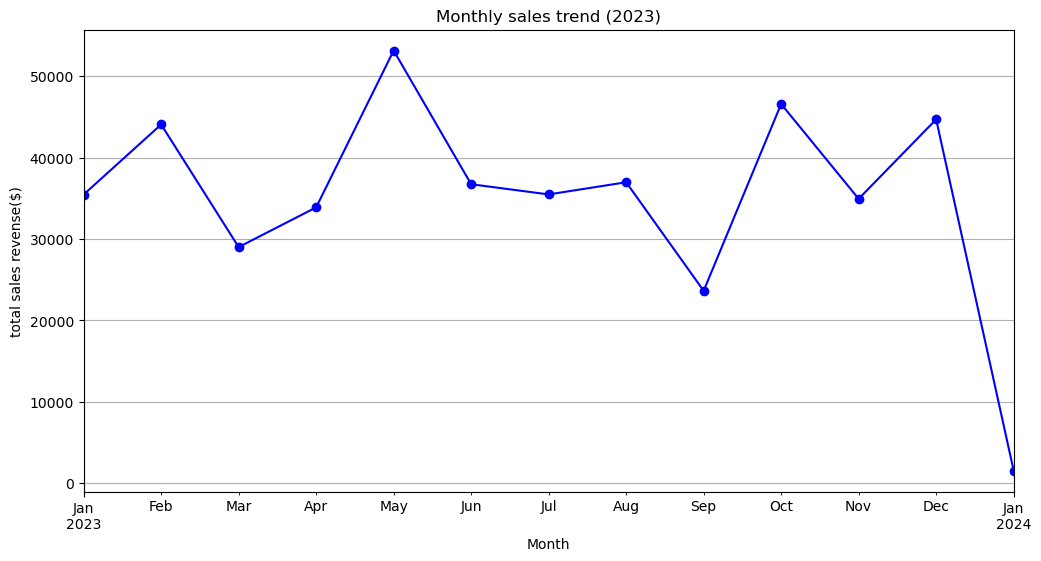

In [10]:
#plot the results
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line',marker='o',color='b')
plt.title("Monthly sales trend (2023)")
plt.xlabel('Month')
plt.ylabel("total sales revense($)")
plt.grid(True)
plt.show()

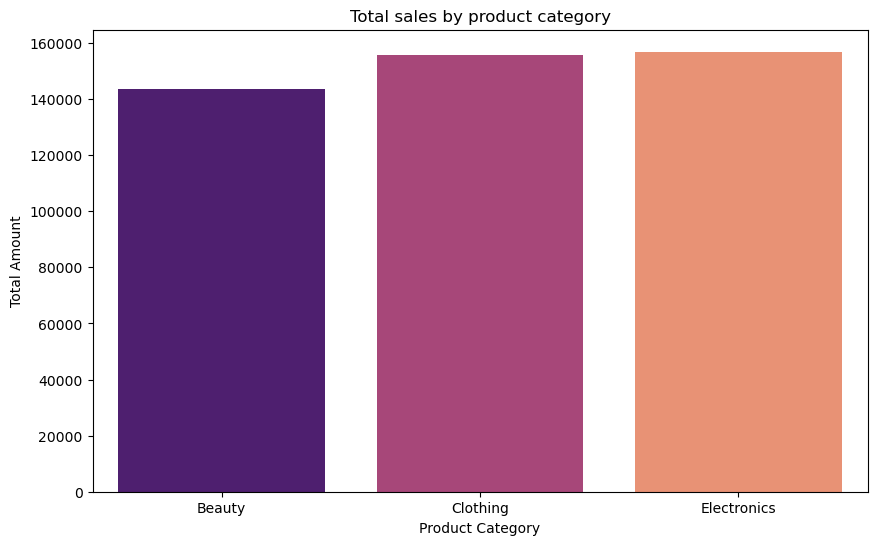

In [18]:
#4.customer and product analysis
plt.figure(figsize=(10,6))
sns.barplot(x='Product Category',y='Total Amount',data=df,estimator=sum,palette='magma',hue='Product Category',legend=False,errorbar=None)
plt.title("Total sales by product category")
plt.show()

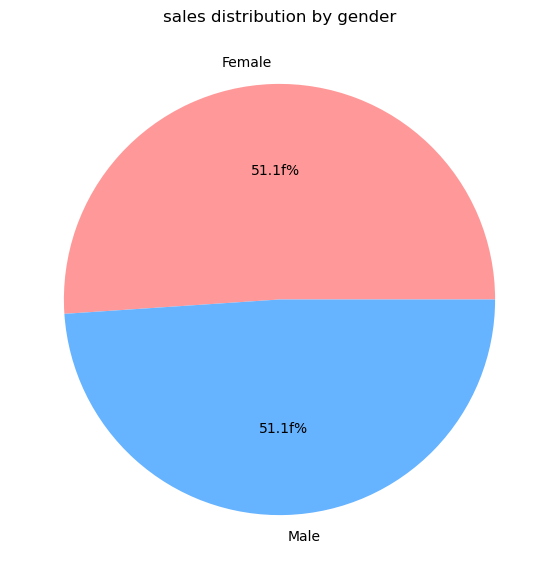

In [12]:
#sdales by gemder
plt.figure(figsize=(7,7))
gender_sales=df.groupby('Gender')['Total Amount'].sum()
plt.pie(gender_sales,labels=gender_sales.index,autopct='51.1f%%',colors=['#ff9999','#66b3ff'])
plt.title("sales distribution by gender")
plt.show()

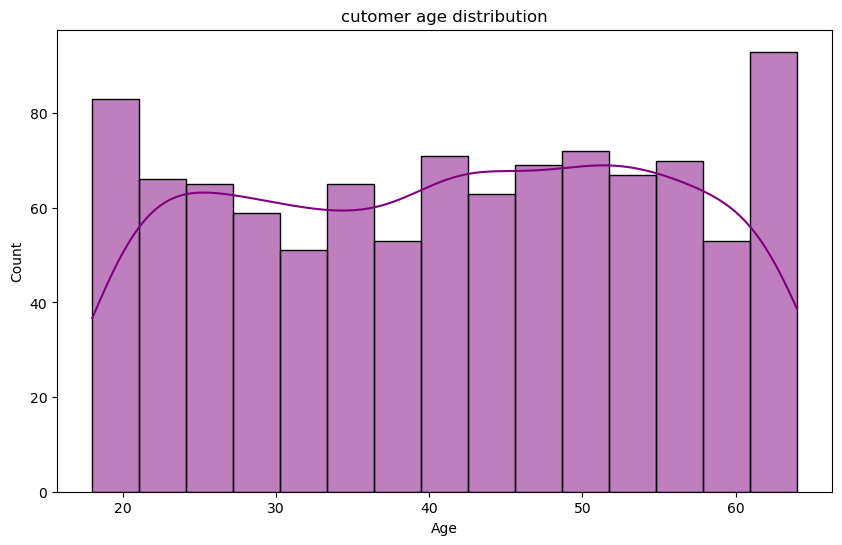

In [13]:
#age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Age'],bins=15,kde=True,color='purple')
plt.title("cutomer age distribution")
plt.show()

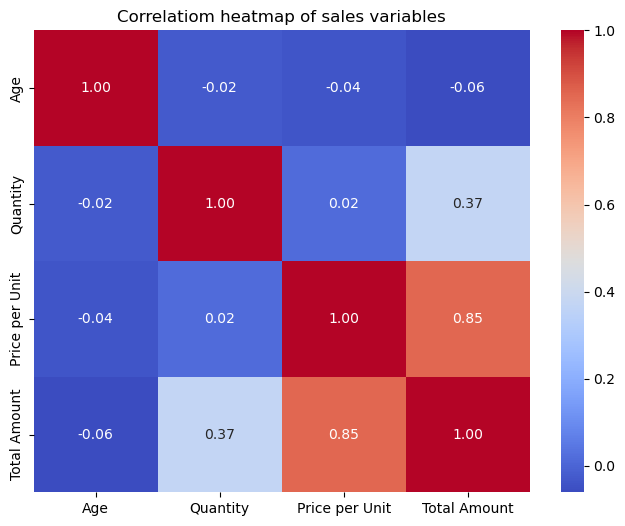

In [14]:
#visulization heatmap
plt.figure(figsize=(8,6))
correlation_matrix=df[['Age','Quantity','Price per Unit','Total Amount']].corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlatiom heatmap of sales variables")
plt.show()
                       

In [15]:
#6.recommendation)printed based on EDA")
print("---Actionable recommendation--")
top_cat=df.groupby("Product Category")['Total Amount'].sum().idxmax()
print(f"1.Inventory:focus on the '{top_cat}'category as if generate the most revenue")


---Actionable recommendation--
1.Inventory:focus on the 'Electronics'category as if generate the most revenue


In [16]:
avg_age=df['Age'].mean()
print(f"2.Marketing: Your average customer age is {avg_age:.0f}. Tailor advertising campaigns to this demographic.")

2.Marketing: Your average customer age is 41. Tailor advertising campaigns to this demographic.


In [17]:
print("3.seasonality:Review the line plot for months with low sales and plan 'Flash Sales'or discount events for those  periods")

3.seasonality:Review the line plot for months with low sales and plan 'Flash Sales'or discount events for those  periods
